<a href="https://colab.research.google.com/github/s34836/HTW_DS/blob/main/Exercise_Sheet_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Learning - Exercise Sheet 2

Notebook solution for Exercises 1--5.

Assumption: the required CSV files are located in the root/current working directory:

- `BostonHousing.csv`
- `weekly.csv`

The notebook is written so that each exercise can be run independently after the import/setup cells.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.datasets import load_iris

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## Exercise 1: Gradient Descent Method

We estimate the parameters of simple linear regression

\[
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
\]

by minimizing

\[
J(\beta)=\frac{1}{n}\sum_{i=1}^{n}(y_i-\beta_0-\beta_1x_i)^2.
\]

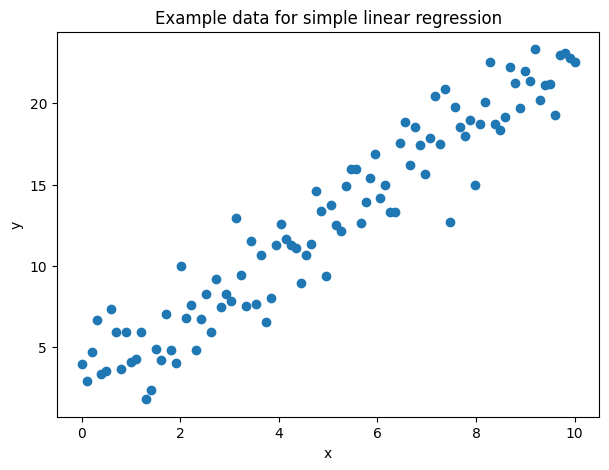

In [2]:
# Example data for demonstrating gradient descent
np.random.seed(RANDOM_STATE)

n = 100
x = np.linspace(0, 10, n)
y = 3.0 + 2.0 * x + np.random.normal(0, 2, size=n)

plt.figure(figsize=(7, 5))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Example data for simple linear regression")
plt.show()

In [3]:
def mse_loss(beta_0, beta_1, x, y):
    y_hat = beta_0 + beta_1 * x
    return np.mean((y - y_hat) ** 2)


def gradient_descent_simple_lr(x, y, alpha=0.01, n_iter=5000):
    beta_0 = 0.0
    beta_1 = 0.0
    n = len(y)
    history = []

    for t in range(n_iter):
        residuals = y - beta_0 - beta_1 * x
        grad_beta_0 = -(2 / n) * np.sum(residuals)
        grad_beta_1 = -(2 / n) * np.sum(x * residuals)

        beta_0 -= alpha * grad_beta_0
        beta_1 -= alpha * grad_beta_1

        if t % 50 == 0:
            history.append(mse_loss(beta_0, beta_1, x, y))

    return beta_0, beta_1, history

beta_0_gd, beta_1_gd, loss_history = gradient_descent_simple_lr(x, y, alpha=0.01, n_iter=5000)

print(f"Estimated beta_0: {beta_0_gd:.4f}")
print(f"Estimated beta_1: {beta_1_gd:.4f}")
print(f"Final MSE: {mse_loss(beta_0_gd, beta_1_gd, x, y):.4f}")

Estimated beta_0: 2.6544
Estimated beta_1: 2.0276
Final MSE: 3.2596


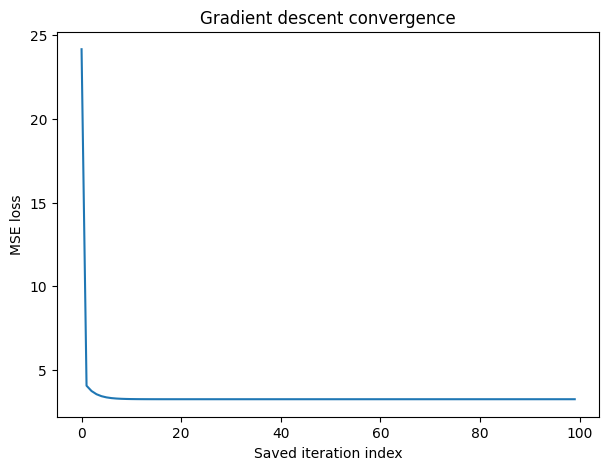

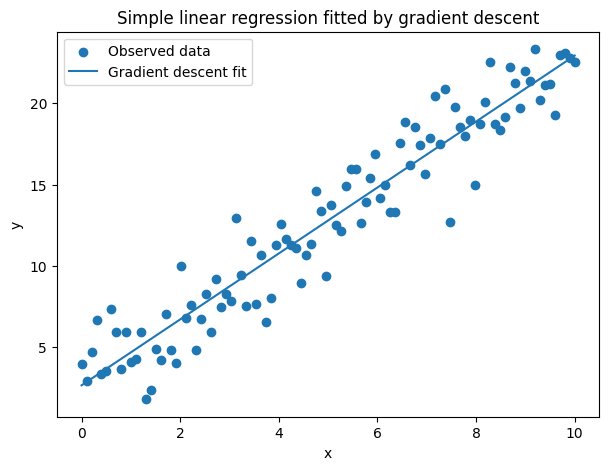

In [4]:
plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Saved iteration index")
plt.ylabel("MSE loss")
plt.title("Gradient descent convergence")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(x, y, label="Observed data")
plt.plot(x, beta_0_gd + beta_1_gd * x, label="Gradient descent fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple linear regression fitted by gradient descent")
plt.legend()
plt.show()

## Exercise 2: Linear Regression -- Regularization

The goal is to predict the crime rate `CRIM` from selected Boston Housing variables. The CSV file is assumed to be available as `BostonHousing.csv` in the current working directory.

In [5]:
boston = pd.read_csv("BostonHousing.csv")

print("Shape:", boston.shape)
display(boston.head())
display(boston.describe())
boston.info()

Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
# Normalize column names to uppercase for easier handling if the CSV uses lowercase names
boston.columns = [c.upper() for c in boston.columns]

print(boston.columns.tolist())
print("\nMissing values:")
print(boston.isna().sum())

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


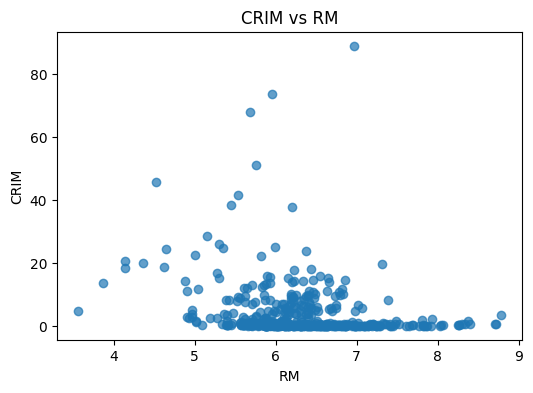

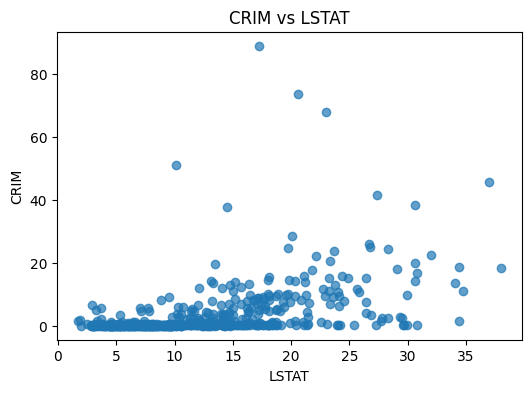

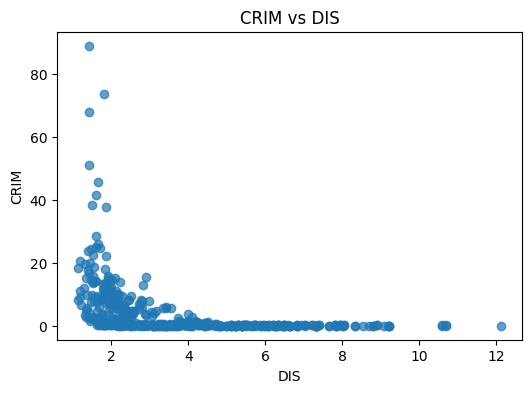

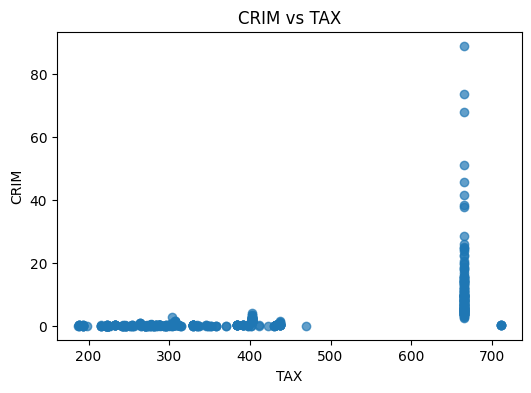

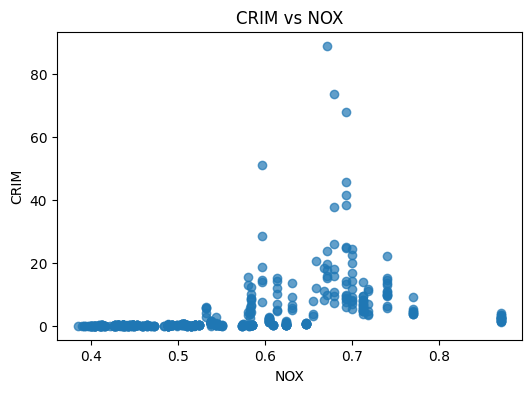

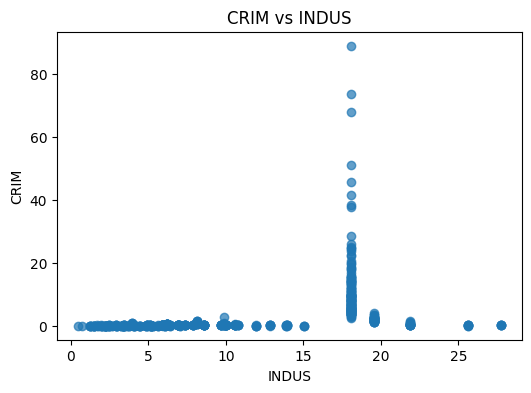

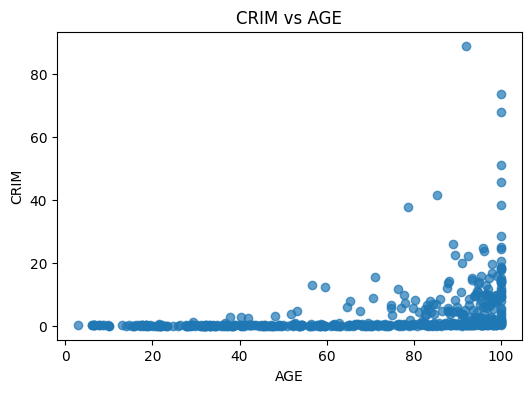

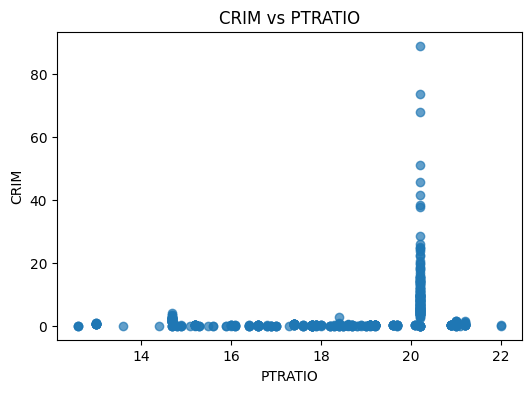

In [7]:
# Scatterplots against CRIM
candidate_features = ["RM", "LSTAT", "DIS", "TAX", "NOX", "INDUS", "AGE", "PTRATIO"]
features_available = [c for c in candidate_features if c in boston.columns]

for col in features_available:
    plt.figure(figsize=(6, 4))
    plt.scatter(boston[col], boston["CRIM"], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("CRIM")
    plt.title(f"CRIM vs {col}")
    plt.show()

In [8]:
# Correlation with CRIM
corr_with_crim = boston.corr(numeric_only=True)["CRIM"].sort_values(ascending=False)
display(corr_with_crim.to_frame("correlation_with_CRIM"))

,correlation_with_CRIM
CRIM,1.000000
RAD,0.625505
TAX,0.582764
LSTAT,0.455621
NOX,0.420972
INDUS,0.406583
AGE,0.352734
PTRATIO,0.289946
CHAS,-0.055892
ZN,-0.200469


In [9]:
# Multivariate linear regression and lasso regression
selected_features = [c for c in ["RM", "LSTAT", "DIS", "TAX", "NOX"] if c in boston.columns]

X = boston[selected_features]
y = boston["CRIM"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000))
])
lasso_model.fit(X_train, y_train)

models = {
    "Linear Regression": linear_model,
    "Lasso Regression": lasso_model,
}

for name, model in models.items():
    pred = model.predict(X_test)
    print(name)
    print("MAE:", round(mean_absolute_error(y_test, pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 4))
    print("R2:", round(r2_score(y_test, pred), 4))
    print()

Linear Regression
MAE: 3.2556
RMSE: 5.4737
R2: 0.4562

Lasso Regression
MAE: 3.235
RMSE: 5.4709
R2: 0.4568



In [10]:
# Coefficient comparison
linear_coef = pd.Series(linear_model.coef_, index=selected_features, name="linear_regression")
lasso_coef = pd.Series(
    lasso_model.named_steps["lasso"].coef_,
    index=selected_features,
    name="lasso_scaled_features"
)

coef_table = pd.concat([linear_coef, lasso_coef], axis=1)
display(coef_table)

,linear_regression,lasso_scaled_features
RM,0.549295,0.141504
LSTAT,0.232465,1.309297
DIS,-0.425642,-0.529252
TAX,0.027189,4.288778
NOX,-8.370275,-0.318897


## Exercise 3: Subset Selection

Subset selection searches for a smaller subset of predictors that explains the response variable well. Below is a simple forward selection example for the Boston Housing data. The criterion used here is test-set RMSE.

In [11]:
def evaluate_feature_subset(data, features, target="CRIM"):
    X = data[list(features)]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return rmse

numeric_features = [c for c in boston.select_dtypes(include=[np.number]).columns if c != "CRIM"]

remaining = numeric_features.copy()
selected = []
steps = []

while remaining:
    candidates = []
    for feature in remaining:
        candidate_features = selected + [feature]
        rmse = evaluate_feature_subset(boston, candidate_features, target="CRIM")
        candidates.append((feature, rmse))

    best_feature, best_rmse = min(candidates, key=lambda x: x[1])
    selected.append(best_feature)
    remaining.remove(best_feature)
    steps.append({
        "step": len(selected),
        "added_feature": best_feature,
        "features": selected.copy(),
        "test_rmse": best_rmse,
    })

forward_selection_results = pd.DataFrame(steps)
display(forward_selection_results[["step", "added_feature", "test_rmse"]])

,step,added_feature,test_rmse
0,1,RAD,5.481529
1,2,LSTAT,5.032020
2,3,B,4.917883
3,4,ZN,4.874475
4,5,INDUS,4.861092
5,6,DIS,4.813298
6,7,TAX,4.812605
7,8,PTRATIO,4.815411
8,9,NOX,4.813931
9,10,RM,4.825955


In [12]:
best_step = forward_selection_results.loc[forward_selection_results["test_rmse"].idxmin()]
print("Best step:", int(best_step["step"]))
print("Best feature subset:", best_step["features"])
print("Best test RMSE:", round(best_step["test_rmse"], 4))

Best step: 7
Best feature subset: ['RAD', 'LSTAT', 'B', 'ZN', 'INDUS', 'DIS', 'TAX']
Best test RMSE: 4.8126


## Exercise 4: Logistic Regression

The `Weekly` data set contains weekly stock-market returns and a binary target variable `Direction`, where the market went either `UP` or `DOWN`. The CSV file is assumed to be available as `weekly.csv` in the current working directory.

In [14]:
weekly = pd.read_csv("Weekly.csv")

print("Shape:", weekly.shape)
display(weekly.head())
display(weekly.describe())
weekly.info()

Shape: (1089, 9)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


In [15]:
# Normalize column names in case of minor capitalization differences
weekly.columns = [c.strip() for c in weekly.columns]

print(weekly.columns.tolist())
print("\nDirection counts:")
print(weekly["Direction"].value_counts())

['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction']

Direction counts:
Direction
Up      605
Down    484
Name: count, dtype: int64


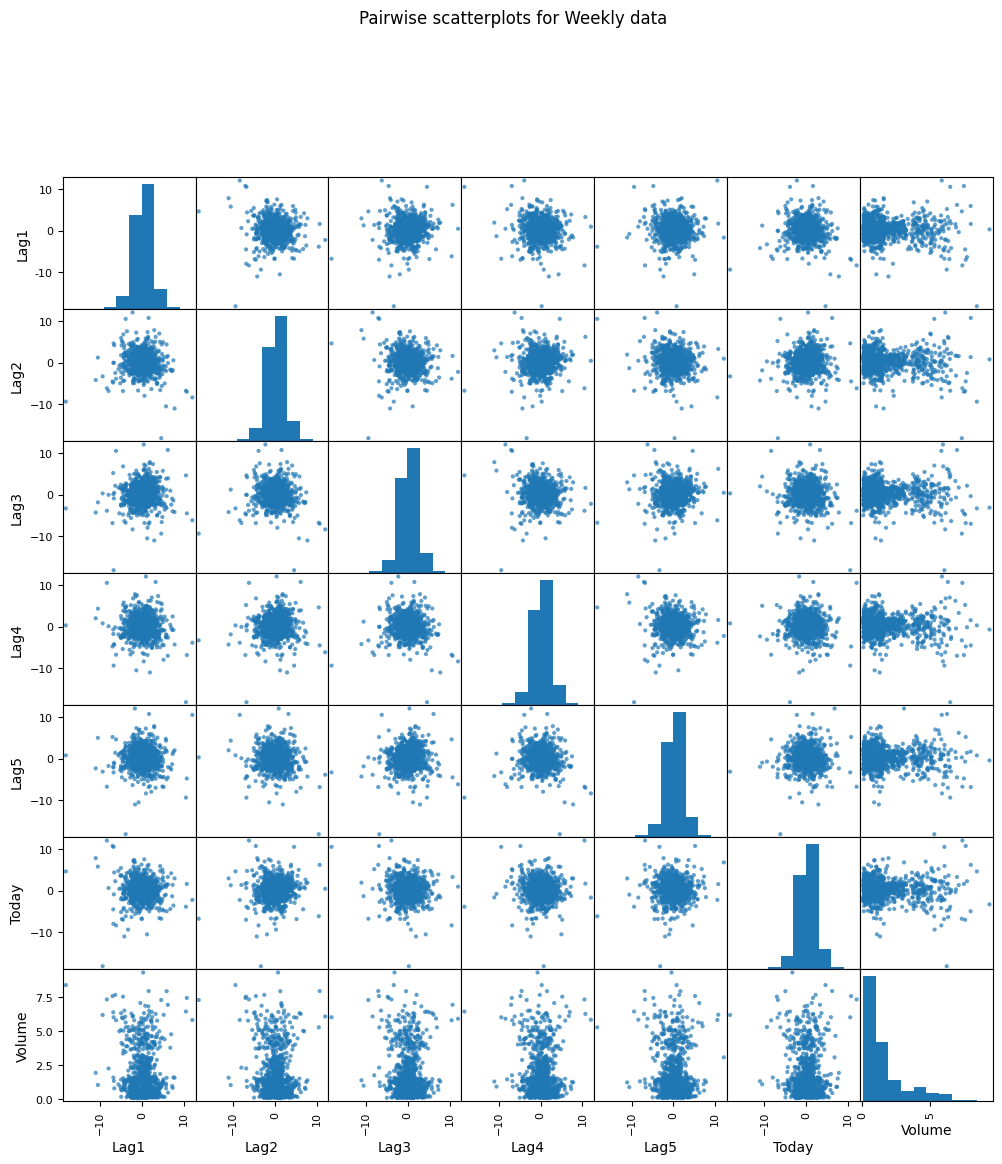

In [16]:
# Pairwise scatterplots for selected numeric variables
scatter_vars = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Today", "Volume"]
scatter_vars = [c for c in scatter_vars if c in weekly.columns]

pd.plotting.scatter_matrix(
    weekly[scatter_vars],
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.7
)
plt.suptitle("Pairwise scatterplots for Weekly data", y=1.02)
plt.show()

In [17]:
# Logistic regression using all lag variables
lag_features = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5"]

X = weekly[lag_features]
y = weekly["Direction"]

logit_all = LogisticRegression(max_iter=1000)
logit_all.fit(X, y)

coef_all = pd.Series(logit_all.coef_[0], index=lag_features, name="coefficient")
print("Intercept:", logit_all.intercept_[0])
display(coef_all.to_frame())

Intercept: 0.23029282520379346


,coefficient
Lag1,-0.040081
Lag2,0.060123
Lag3,-0.015062
Lag4,-0.026764
Lag5,-0.013460


In [18]:
# Train-test split: train up to 2008, test from 2009 onward
train_mask = weekly["Year"] <= 2008
test_mask = weekly["Year"] >= 2009

X_train = weekly.loc[train_mask, ["Lag1"]]
y_train = weekly.loc[train_mask, "Direction"]
X_test = weekly.loc[test_mask, ["Lag1"]]
y_test = weekly.loc[test_mask, "Direction"]

logit_lag1 = LogisticRegression(max_iter=1000)
logit_lag1.fit(X_train, y_train)

print("Classes:", logit_lag1.classes_)
print("Intercept:", logit_lag1.intercept_[0])
print("Coefficient for Lag1:", logit_lag1.coef_[0][0])

print("\nFitted model:")
print(f"logit(P(Direction = {logit_lag1.classes_[1]})) = {logit_lag1.intercept_[0]:.4f} + {logit_lag1.coef_[0][0]:.4f} * Lag1")

Classes: ['Down' 'Up']
Intercept: 0.2182541349090448
Coefficient for Lag1: -0.05900252901354506

Fitted model:
logit(P(Direction = Up)) = 0.2183 + -0.0590 * Lag1


[[ 4 39]
 [ 6 55]]
Accuracy: 0.5673

Classification report:
              precision    recall  f1-score   support

        Down       0.40      0.09      0.15        43
          Up       0.59      0.90      0.71        61

    accuracy                           0.57       104
   macro avg       0.49      0.50      0.43       104
weighted avg       0.51      0.57      0.48       104



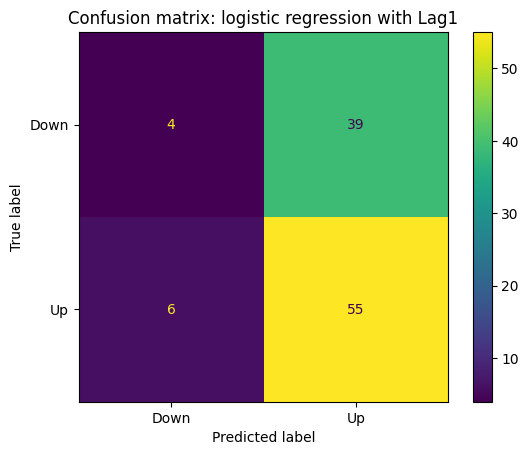

In [19]:
y_pred = logit_lag1.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=logit_lag1.classes_)
print(cm)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay(cm, display_labels=logit_lag1.classes_).plot()
plt.title("Confusion matrix: logistic regression with Lag1")
plt.show()

## Exercise 5: Model Evaluation -- Classification

This exercise investigates ROC curves, precision-recall curves, F-score, and class imbalance.

In [21]:
# Helper functions for binary classification evaluation

def evaluate_binary_classifier(y_true, y_score, threshold=0.5, positive_label=1, title="Model"):
    y_pred = (y_score >= threshold).astype(int)

    print(title)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("F1-score:", round(f1_score(y_true, y_pred, pos_label=positive_label), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_score), 4))
    print("Average precision:", round(average_precision_score(y_true, y_score), 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))


def plot_roc_and_pr(y_true, y_score, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, y_score):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix}: ROC curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"Average precision = {average_precision_score(y_true, y_score):.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix}: Precision-Recall curve")
    plt.legend()
    plt.show()

In [22]:
# Load Iris and reduce it to binary classification: setosa vs versicolor
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

binary_iris = iris_df[iris_df["species"].isin(["setosa", "versicolor"])].copy()
binary_iris["target_binary"] = (binary_iris["species"] == "versicolor").astype(int)

print(binary_iris["species"].value_counts())
display(binary_iris.head())

species
setosa        50
versicolor    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,target_binary
0,5.1,3.5,1.4,0.2,0,setosa,0
1,4.9,3.0,1.4,0.2,0,setosa,0
2,4.7,3.2,1.3,0.2,0,setosa,0
3,4.6,3.1,1.5,0.2,0,setosa,0
4,5.0,3.6,1.4,0.2,0,setosa,0


In [23]:
# Balanced binary Iris data set
X_balanced = binary_iris[iris.feature_names]
y_balanced = binary_iris["target_binary"]

print("Balanced class counts:")
print(y_balanced.value_counts())

Balanced class counts:
target_binary
0    50
1    50
Name: count, dtype: int64


In [24]:
# Artificially unbalanced data set:
# keep all setosa observations but only a small number of versicolor observations
positive = binary_iris[binary_iris["target_binary"] == 1]
negative = binary_iris[binary_iris["target_binary"] == 0]

positive_small = positive.sample(n=10, random_state=RANDOM_STATE)
unbalanced_iris = pd.concat([negative, positive_small], axis=0).sample(frac=1, random_state=RANDOM_STATE)

X_unbalanced = unbalanced_iris[iris.feature_names]
y_unbalanced = unbalanced_iris["target_binary"]

print("Unbalanced class counts:")
print(y_unbalanced.value_counts())

Unbalanced class counts:
target_binary
0    50
1    10
Name: count, dtype: int64


Balanced Iris classifier
Accuracy: 1.0
F1-score: 1.0
ROC-AUC: 1.0
Average precision: 1.0
Confusion matrix:
[[15  0]
 [ 0 15]]


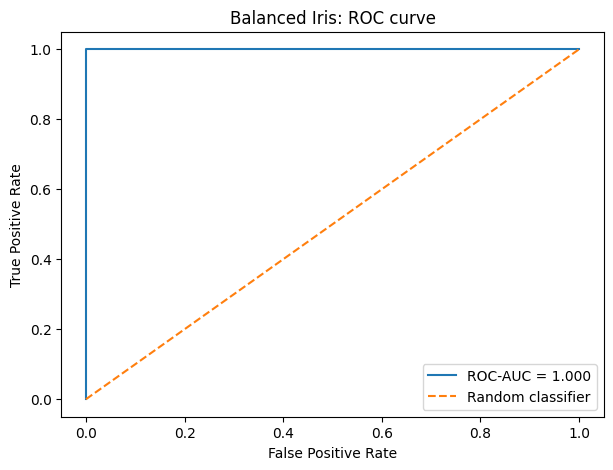

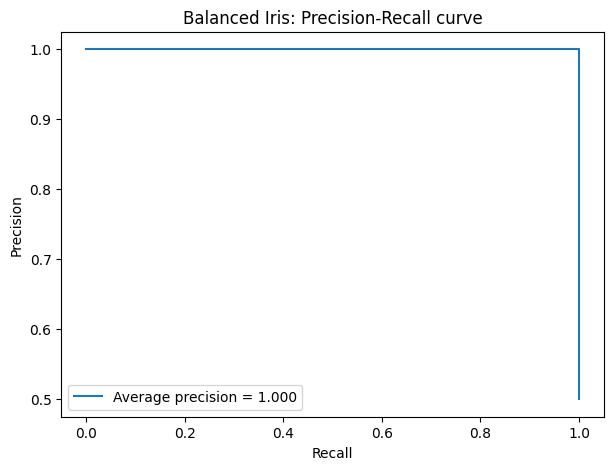

In [25]:
# Train and evaluate logistic regression on balanced data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_balanced, y_balanced,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

clf_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])
clf_balanced.fit(X_train_b, y_train_b)

score_balanced = clf_balanced.predict_proba(X_test_b)[:, 1]
evaluate_binary_classifier(y_test_b, score_balanced, title="Balanced Iris classifier")
plot_roc_and_pr(y_test_b, score_balanced, title_prefix="Balanced Iris")

Unbalanced Iris classifier
Accuracy: 1.0
F1-score: 1.0
ROC-AUC: 1.0
Average precision: 1.0
Confusion matrix:
[[15  0]
 [ 0  3]]


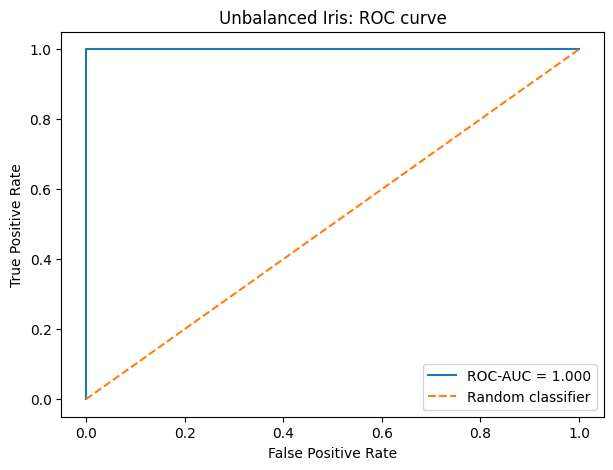

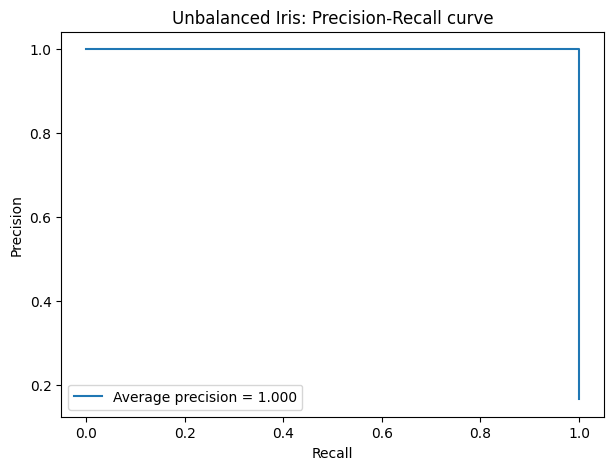

In [26]:
# Train and evaluate logistic regression on unbalanced data
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unbalanced, y_unbalanced,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_unbalanced
)

clf_unbalanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])
clf_unbalanced.fit(X_train_u, y_train_u)

score_unbalanced = clf_unbalanced.predict_proba(X_test_u)[:, 1]
evaluate_binary_classifier(y_test_u, score_unbalanced, title="Unbalanced Iris classifier")
plot_roc_and_pr(y_test_u, score_unbalanced, title_prefix="Unbalanced Iris")

In [27]:
# Direct comparison of F1-score, ROC-AUC, and average precision
comparison = pd.DataFrame({
    "dataset": ["balanced", "unbalanced"],
    "positive_fraction": [y_balanced.mean(), y_unbalanced.mean()],
    "f1_score": [
        f1_score(y_test_b, (score_balanced >= 0.5).astype(int)),
        f1_score(y_test_u, (score_unbalanced >= 0.5).astype(int)),
    ],
    "roc_auc": [
        roc_auc_score(y_test_b, score_balanced),
        roc_auc_score(y_test_u, score_unbalanced),
    ],
    "average_precision": [
        average_precision_score(y_test_b, score_balanced),
        average_precision_score(y_test_u, score_unbalanced),
    ],
})

display(comparison)

,dataset,positive_fraction,f1_score,roc_auc,average_precision
0,balanced,0.500000,1.0,1.0,1.0
1,unbalanced,0.166667,1.0,1.0,1.0


## Final notes

- ROC curves are usually less sensitive to class imbalance because both TPR and FPR are normalized by the number of positives and negatives separately.
- Precision-recall curves are more sensitive to class imbalance because precision directly depends on false positives.
- F1-score is also sensitive to class imbalance because it combines precision and recall.